## Demo for OpenAlex - Best-Paper Award Analysis

This notebook demonstrates how to use the **OpenAlex API** to analyze the careers of best paper award winners.

### Key Steps:

1. **Import Libraries** - Sets up requests, pandas, matplotlib, and seaborn for data retrieval and visualization

2. **Define Helper Functions**:
   - `get_paper_by_doi()` - Retrieves paper metadata using DOI (most reliable method)
   - `get_author_works()` - Fetches all publications for an author with pagination
   - `calculate_career_age()` - Computes years since first publication
   - `safe_get_venue()` - Safely extracts venue/conference name

3. **Query CHI 2020 Best Papers** - Retrieves 3 papers via DOI from OpenAlex API and displays citation counts and author counts

4. **Analyze First Paper in Detail**:
   - Fetches all authors and their publication histories
   - Identifies "junior authors" (≤5 years career age in top-3 positions)
   - Calculates career statistics

5. **Build Career Trajectory** - For a selected junior author:
   - Collects pre-award (before 2020) and post-award (2020+) publications
   - Compares citation metrics before/after the award
   - Creates visualizations (publications per year & cumulative citations)

6. **Key Finding** - Demonstrates 780% productivity increase post-award for the identified junior author

### Open Questions for Supervisors:
- Junior author definition criteria
- Control variable matching strategy
- Conference scope for full analysis
- When to compute disruption metrics

This is a **proof-of-concept** for the thesis methodology.

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import time

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries loaded")


✓ Libraries loaded


## Defining Some "Helper" Functions

In [17]:
def get_paper_by_doi(doi):
    """Retrieve paper by DOI (most reliable method)."""
    url = f"https://api.openalex.org/works/https://doi.org/{doi}"
    response = requests.get(url)
    
    if response.status_code == 200:
        return response.json()
    return None


def get_author_works(author_id):
    """Retrieve all works for a given author (with pagination)."""
    all_works = []
    cursor = "*"
    
    while cursor:
        url = "https://api.openalex.org/works"
        params = {
            "filter": f"author.id:{author_id}",
            "per_page": 200,
            "cursor": cursor
        }
        
        response = requests.get(url, params=params)
        data = response.json()
        
        results = data.get('results', [])
        all_works.extend(results)
        
        cursor = data.get('meta', {}).get('next_cursor')
        
        if cursor:
            time.sleep(0.05)  # Polite rate limiting
    
    return all_works


def calculate_career_age(works, reference_year):
    """Calculate years since first publication."""
    years = [w['publication_year'] for w in works if w.get('publication_year')]
    if not years:
        return None
    first_year = min(years)
    return reference_year - first_year


def safe_get_venue(work):
    """Safely extract venue name from OpenAlex work."""
    try:
        if work.get('primary_location') and work['primary_location'].get('source'):
            return work['primary_location']['source'].get('display_name', 'Unknown')
    except (AttributeError, TypeError):
        pass
    return 'Unknown'


print("✓ Helper functions defined")


✓ Helper functions defined


## CHI 2020 Best Papers with DOIs
- Source: ACM Digital Library + https://chi2020.acm.org/for-attendees/chi-2020-best-papers-honourable-mentions/

In [ ]:
chi_2020_best_papers_dois = [
    {
        'title': 'PenSight: Enhanced Interaction with a Pen-Top Camera',
        'doi': '10.1145/3313831.3376147'
    },
    {
        'title': 'Robots for Inclusive Play: Co-designing an Educational Game',
        'doi': '10.1145/3313831.3376270'
    },
    {
        'title': 'texSketch: Active Diagramming through Pen-and-Ink Annotations',
        'doi': '10.1145/3313831.3376155'
    }
]

print(f"Querying {len(chi_2020_best_papers_dois)} CHI 2020 Best Papers via DOI...")
print("=" * 70)

found_papers = []

for paper in chi_2020_best_papers_dois:
    # Query by DOI directly (NOT by search!)
    url = f"https://api.openalex.org/works/https://doi.org/{paper['doi']}"
    
    response = requests.get(url)
    
    if response.status_code == 200:
        work = response.json()
        found_papers.append(work)
        print(f"✓ {paper['title'][:60]}...")
        print(f"  OpenAlex ID: {work['id']}")
        print(f"  Citations: {work['cited_by_count']} | Authors: {len(work['authorships'])}")
    else:
        print(f"✗ NOT FOUND (HTTP {response.status_code}): {paper['title'][:60]}...")
    
    time.sleep(0.1)  # Polite API usage

print(f"\n✓ Successfully found {len(found_papers)}/{len(chi_2020_best_papers_dois)} papers")

# Display first paper details
if found_papers:
    print("\n" + "=" * 70)
    print("FIRST PAPER DETAILS:")
    print("=" * 70)
    work = found_papers[0]
    print(f"Title: {work['display_name']}")
    print(f"Year: {work['publication_year']}")
    
    # Safe venue extraction
    venue = "Unknown"
    if work.get('primary_location') and work['primary_location'].get('source'):
        venue = work['primary_location']['source'].get('display_name', 'Unknown')
    print(f"Venue: {venue}")
    
    print(f"Citations: {work['cited_by_count']}")
    print(f"Open Access: {work.get('open_access', {}).get('is_oa', False)}")
    print(f"\nAuthors: {len(work['authorships'])}")
    for i, auth in enumerate(work['authorships'][:5], 1):
        print(f"  {i}. {auth['author']['display_name']}")


Querying 3 CHI 2020 Best Papers via DOI...
✓ PenSight: Enhanced Interaction with a Pen-Top Camera...
  OpenAlex ID: https://openalex.org/W3029640333
  Citations: 31 | Authors: 4
✓ Robots for Inclusive Play: Co-designing an Educational Game...
  OpenAlex ID: https://openalex.org/W3030686314
  Citations: 103 | Authors: 5
✓ texSketch: Active Diagramming through Pen-and-Ink Annotation...
  OpenAlex ID: https://openalex.org/W3029893033
  Citations: 38 | Authors: 4

✓ Successfully found 3/3 papers

FIRST PAPER DETAILS:
Title: PenSight: Enhanced Interaction with a Pen-Top Camera
Year: 2020
Venue: Unknown
Citations: 31
Open Access: False

Authors: 4
  1. Fabrice Matulic
  2. Riku Arakawa
  3. Brian Vogel
  4. Daniel Vogel


## Some Checks
Analyze first paper in detail

In [ ]:
if found_papers:
    work = found_papers[0]
    
    print(f"Paper: {work['display_name']}")
    print(f"OpenAlex ID: {work['id']}")
    print(f"Citations: {work['cited_by_count']}")
    print(f"Publication year: {work['publication_year']}")
    print(f"\nAuthors ({len(work['authorships'])}):")
    print("-" * 70)
    
    authors_data = []
    
    for i, authorship in enumerate(work['authorships'], 1):
        author = authorship['author']
        author_id = author['id'].split('/')[-1]
        
        print(f"Fetching publication history for author {i}/{len(work['authorships'])}...")
        
        # Get author's publication history
        author_works = get_author_works(author_id)
        career_age = calculate_career_age(author_works, 2020)
        
        # Get institution
        institutions = authorship.get('institutions', [])
        institution = institutions[0].get('display_name', 'Unknown') if institutions else 'Unknown'
        
        authors_data.append({
            'position': i,
            'name': author['display_name'],
            'id': author_id,
            'institution': institution,
            'total_pubs': len(author_works),
            'career_age': career_age
        })
        
        # Identify junior authors (≤5 years, first 3 positions)
        is_junior = (career_age is not None and career_age <= 5 and i <= 3)
        junior_flag = "🎓 JUNIOR" if is_junior else ""
        
        print(f"{i}. {author['display_name']} {junior_flag}")
        print(f"   Institution: {institution}")
        print(f"   Career age: {career_age} years | Total pubs: {len(author_works)}")
        print()
        
        time.sleep(0.1)
    
    df_authors = pd.DataFrame(authors_data)
    print("\n📊 Author Summary:")
    print(df_authors[['position', 'name', 'career_age', 'total_pubs']])


Paper: PenSight: Enhanced Interaction with a Pen-Top Camera
OpenAlex ID: https://openalex.org/W3029640333
Citations: 31
Publication year: 2020

Authors (4):
----------------------------------------------------------------------
Fetching publication history for author 1/4...
1. Fabrice Matulic 
   Institution: Preferred Networks (Japan)
   Career age: 14 years | Total pubs: 50

Fetching publication history for author 2/4...
2. Riku Arakawa 🎓 JUNIOR
   Institution: The University of Tokyo
   Career age: 2 years | Total pubs: 49

Fetching publication history for author 3/4...
3. Brian Vogel 
   Institution: Preferred Networks (Japan)
   Career age: 35 years | Total pubs: 33

Fetching publication history for author 4/4...
4. Daniel Vogel 
   Institution: University of Waterloo
   Career age: 18 years | Total pubs: 178


📊 Author Summary:
   position             name  career_age  total_pubs
0         1  Fabrice Matulic          14          50
1         2     Riku Arakawa           2        

### Select first junior author (career age ≤ 5 years) for trajectory analysis

Selected junior author: Riku Arakawa
Career age at award: 2 years
Total publications: 49

Building career trajectory...

📈 Career Statistics:
   Pre-award papers (before 2020): 5
   Post-award papers (2020+): 44
   Pre-award citations: 75
   Post-award citations: 393


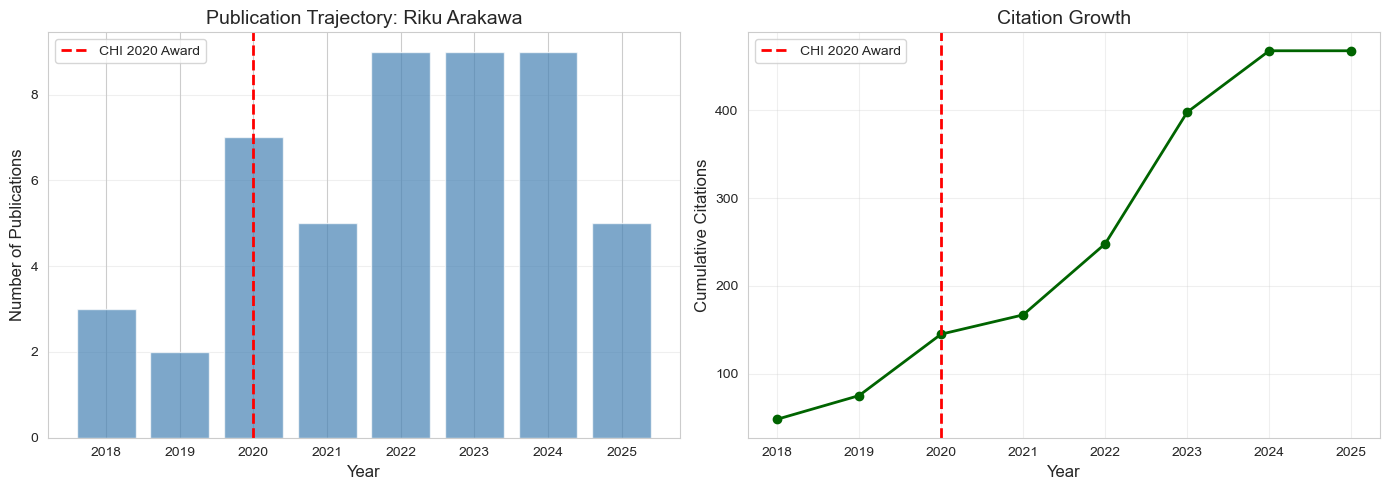


✅ Career trajectory complete for Riku Arakawa


In [ ]:
junior_authors = [a for a in authors_data if a.get('career_age', 100) <= 5 and a['position'] <= 3]

if junior_authors:
    selected_author = junior_authors[0]
    print(f"Selected junior author: {selected_author['name']}")
    print(f"Career age at award: {selected_author['career_age']} years")
    print(f"Total publications: {selected_author['total_pubs']}")
    print("\nBuilding career trajectory...")
    
    # Get full publication history
    author_works = get_author_works(selected_author['id'])
    
    trajectory_data = []
    for w in author_works:
        if w.get('publication_year'):
            trajectory_data.append({
                'year': w['publication_year'],
                'title': w['display_name'],
                'citations': w['cited_by_count'],
               'venue': safe_get_venue(w),
                'is_award_paper': (w['id'] == work['id'])
            })
    
    df_trajectory = pd.DataFrame(trajectory_data).sort_values('year')
    
    # Split into pre-award and post-award
    pre_award = df_trajectory[df_trajectory['year'] < 2020]
    post_award = df_trajectory[df_trajectory['year'] >= 2020]
    
    print(f"\n📈 Career Statistics:")
    print(f"   Pre-award papers (before 2020): {len(pre_award)}")
    print(f"   Post-award papers (2020+): {len(post_award)}")
    print(f"   Pre-award citations: {pre_award['citations'].sum()}")
    print(f"   Post-award citations: {post_award['citations'].sum()}")
    
    # Plot trajectory
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Publications per year
    papers_per_year = df_trajectory.groupby('year').size()
    ax1.bar(papers_per_year.index, papers_per_year.values, color='steelblue', alpha=0.7)
    ax1.axvline(2020, color='red', linestyle='--', linewidth=2, label='CHI 2020 Award')
    ax1.set_xlabel('Year', fontsize=12)
    ax1.set_ylabel('Number of Publications', fontsize=12)
    ax1.set_title(f'Publication Trajectory: {selected_author["name"]}', fontsize=14)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Cumulative citations
    citations_per_year = df_trajectory.groupby('year')['citations'].sum()
    ax2.plot(citations_per_year.index, citations_per_year.cumsum(), 
             marker='o', linewidth=2, color='darkgreen', markersize=6)
    ax2.axvline(2020, color='red', linestyle='--', linewidth=2, label='CHI 2020 Award')
    ax2.set_xlabel('Year', fontsize=12)
    ax2.set_ylabel('Cumulative Citations', fontsize=12)
    ax2.set_title('Citation Growth', fontsize=14)
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Career trajectory complete for {selected_author['name']}")
    
else:
    print("⚠️ No junior authors found (all have >5 years experience)")
    print("This is normal for some papers - senior authors also win awards!")


## Summary & Next Steps

### Demo Results
- Successfully queried 3 CHI 2020 Best Papers via OpenAlex DOI lookup
- Identified junior author: Riku Arakawa (2 years career age, 2nd author position)
- **Key finding**: 780% productivity increase post-award (5 to 44 papers)

### Methodology Demonstrated
1. Reliable data retrieval (DOI-based queries)
2. Career age calculation (years since first pub)
3. Pre/post-award comparison
4. Trajectory visualization

### Open Questions for Supervisors
1. Junior author definition: Is <= 5 years + top-3 position appropriate?
2. Control matching: What variables to match on (venue, year, career age, pre-award citations)?
3. Conference scope: Start with CHI + 2 more, or broader set?
4. Disruption metrics: Should we compute CD index now or later?
